In [546]:
import pandas as pd
import numpy as np
import streamlit as slt

In [547]:
import matplotlib.pyplot as plt

In [548]:
df = pd.read_csv('incidents.csv')

In [549]:
df[["Incident","State"]] = df["Title"].str.split(",", n=1,expand=True)

In [550]:
df.head(5)

,Identifier,Title,Start date,End date,Number of deaths,Incident,State
0,IBD031681,"Food Poisoning, Imo",2025-04-18,2025-04-18,1,Food Poisoning,Imo
1,IBD032064,"Gunmen Kill Man, Benue",2025-03-31,2025-03-31,1,Gunmen Kill Man,Benue
2,IBD032058,"Auto Crash, Lagos",2025-03-31,2025-03-31,1,Auto Crash,Lagos
3,IBD032066,"Stray Bullets, Sokoto",2025-03-31,2025-03-31,1,Stray Bullets,Sokoto
4,IBD032062,"Lightening Kills Herder, Kaduna",2025-03-30,2025-03-30,1,Lightening Kills Herder,Kaduna


In [551]:
df.isna().sum()

Identifier           0
Title                0
Start date           0
End date             0
Number of deaths     0
Incident             0
State               17
dtype: int64

In [552]:
df = df.drop_duplicates()

In [553]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7485 entries, 0 to 7499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Identifier        7485 non-null   object
 1   Title             7485 non-null   object
 2   Start date        7485 non-null   object
 3   End date          7485 non-null   object
 4   Number of deaths  7485 non-null   int64 
 5   Incident          7485 non-null   object
 6   State             7468 non-null   object
dtypes: int64(1), object(6)
memory usage: 467.8+ KB


In [554]:
df = df.drop(columns=['Title'])

In [555]:
df.head(3)

,Identifier,Start date,End date,Number of deaths,Incident,State
0,IBD031681,2025-04-18,2025-04-18,1,Food Poisoning,Imo
1,IBD032064,2025-03-31,2025-03-31,1,Gunmen Kill Man,Benue
2,IBD032058,2025-03-31,2025-03-31,1,Auto Crash,Lagos


In [556]:
df["State"] =df["State"].str.strip()

In [557]:
Replace_map ={ 60:"Delta",  78: "Benue",171:"Edo", 
 330: "Imo", 837: "Delta", 857:"Edo", 858:"Lagos",
  865:"Kastina", 1768:"(FCT) Abuja",
1800:"(FCT) Abuja", 2318: "(FCT) Abuja", 2875:"Akwa Ibom", 
2889: "Delta2", 2932:"Abuja",  3888:"Edo", 5182:"(FCT) Abuja", 
6049:"Jigawa", 6136:"Kaduna" ,
6321:"Lagos", 6884:"Edo"} 

for idx , val in Replace_map.items():
    if pd.isna(df.loc[idx, "State"]) or df.loc[idx,"State"].strip() =="":
        df.loc[idx, "State"] =val

In [558]:
aso = ['FCT','FCT (Abuja)','FCT, Abuja', 'FCT, (Abuja)','FCT(Abuja)',
'Hamza Musa', 'Vigilantes vs Herders, FCT (Abuja)','Abuja (FCT)', '(Fct) Abuja' 
]

mask = df['State'].isin(aso)
df.loc[mask, 'State'] = '(FCT) Abuja'

In [559]:
# Clean and standardize State names by correcting typos, removing variations, 
# and replacing inconsistent entries with their proper names

df['State'] = df['State'].replace(['Rivers (Offshore)','Port Harcourt','Bonny','River'], 'Rivers')
df['State'] = df['State'].replace('Bayelsa (Offshore)', 'Bayelsa')
df['State'] = df['State'].replace('Son, Anambra', 'Anambra')
df['State'] = df['State'].replace('Dies, Ogun', 'Ogun')
df['State'] = df['State'].replace(['Worshipper, Delta', 'n','delta'], 'Delta')
df['State'] = df['State'].replace(['Akwa Ibom (Offshore)', 'Uyo','Akwa Ibom'], 'Akwa Ibom')
df['State'] = df['State'].replace('Ondo, Ondo', 'Ondo')
df['State'] = df['State'].replace(['Katsina 2','Katsina 1',' Katisna','Katisna','Katsina'], 'Katsina')
df['State'] = df['State'].replace(['Nasarwa', 'Nasaraawa'], 'Nasarawa')
df['State'] = df['State'].replace('Bornon', 'Borno')
df['State'] = df['State'].replace(['Jigaawa','Jiagawa','Jigiwa'], 'Jigawa')
df['State'] = df['State'].replace(['Kadauna','Kadun'], 'Kaduna')
df['State'] = df['State'].replace(['Anmabra','ANambra'], 'Anambra')
df['State'] = df['State'].replace('Taraba`', 'Taraba')
df['State'] = df['State'].replace('Katisna', 'Katsina')
df['State'] = df['State'].replace('Zamafara', 'Zamfara')
df['State'] = df['State'].replace('Cross RIvers', 'Cross River')
df['State'] = df['State'].replace('Niger State', 'Niger')
df['State'] = df['State'].replace('(Fct) Abuja', '(FCT) Abuja')

In [560]:
# Clean specific rows in the 'Incident' column by removing unwanted state names 

df.loc[60, "Incident"] = df.loc[60, "Incident"].replace(". Delta", "").strip()
df.loc[78, "Incident"] = df.loc[78, "Incident"].replace(" Benue", "").strip()
df.loc[171, "Incident"] = df.loc[171, "Incident"].replace(" Edo", "").strip()
df.loc[3888, "Incident"] = df.loc[388, "Incident"].replace(". Edo", "").strip()

In [561]:
df['Start date'] = pd.to_datetime(df['Start date'],format='mixed', errors='coerce')
df['End date'] = pd.to_datetime(df['End date'],format='mixed', errors='coerce')

In [562]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7485 entries, 0 to 7499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Identifier        7485 non-null   object        
 1   Start date        7484 non-null   datetime64[ns]
 2   End date          7484 non-null   datetime64[ns]
 3   Number of deaths  7485 non-null   int64         
 4   Incident          7485 non-null   object        
 5   State             7485 non-null   object        
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 667.4+ KB


In [563]:
#Capitalize each First letter to Capital in the state
df['State'] = df['State'].str.title()

In [564]:
df['State'] = df['State'].replace("(Fct) Abuja","(FCT) Abuja")

In [565]:
df['State'] = df['State'].str.strip().str.lower()

In [566]:
df['State'] = df['State'].replace({
    'abuja': '(fct) abuja',
    'fct ( abuja)': '(fct) abuja',
    'fct, ( abuja)': '(fct) abuja',
    
    'delta2': 'delta',
    
    'kastina': 'katsina',
    'katisna': 'katsina'
})

In [567]:
df['State'] = df['State'].str.title()

In [568]:
df['State'] = df['State'].replace('(Fct) Abuja', '(FCT) Abuja')

In [569]:
clean_map = {
    'abuja': '(fct) abuja',
    'fct ( abuja)': '(fct) abuja',
    'fct, ( abuja)': '(fct) abuja',
    'delta2': 'delta',
    'kastina': 'katsina',
    'katisna': 'katsina'
}

df['State'] = df['State'].replace(clean_map)

In [570]:
asf = df['State'].nunique()
print(asf, "states")

37 states


In [571]:
df['State'].value_counts().head(10)

df['Incident'].value_counts().head(10)

df['Number of deaths'].describe()

count    7485.000000
mean        4.711824
std        11.165974
min         1.000000
25%         1.000000
50%         1.000000
75%         4.000000
max       244.000000
Name: Number of deaths, dtype: float64

## Research Questions

1. Which states in Nigeria have the highest number of reported incidents?
2. What types of incidents occur most frequently?
3. Which incidents result in the highest number of deaths? 
4. How have the number of incidents changed over time?
5. What is the distribution of deaths across different incidents?
6. Are there specific states that consistently experience high casualty incidents? 
7. Is there a relationship between incident frequency and number of deaths? 

## 1. Which states have the highest number of incidents?

In [572]:
state_counts = df['State'].value_counts().head(10)
state_counts

State
Lagos          626
Ogun           484
Kaduna         464
Delta          352
Benue          328
Niger          326
(FCT) Abuja    319
Borno          315
Anambra        282
Plateau        268
Name: count, dtype: int64

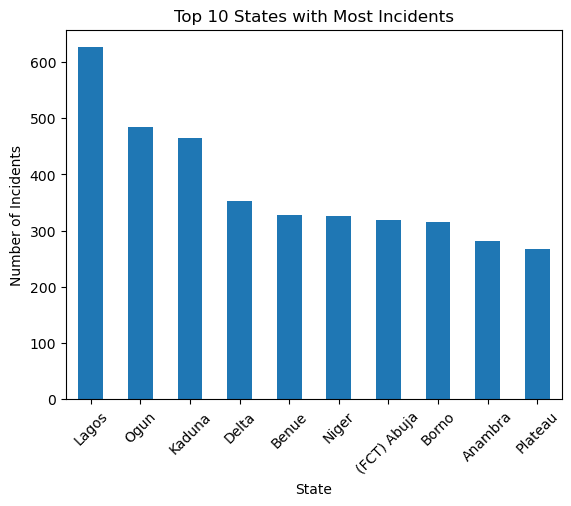

In [573]:
import matplotlib.pyplot as plt
state_counts.plot(kind='bar')
plt.title("Top 10 States with Most Incidents")
plt.xlabel("State")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.show()

States such as Borno, Kaduna, and Zamfara record the highest number of incidents. 
This suggests that these regions are more prone to security challenges and require targeted interventions.

2. What types of incidents occur most frequently?


In [574]:
incident_counts = df['Incident'].value_counts().head(10)
incident_counts

Incident
Auto Crash              1023
Banditry                 288
Gunmen Attack            219
Domestic Violence        160
Flooding                 114
Army vs Bandits          112
Cult Killing             112
Police vs Kidnappers     103
Cult Clash               102
Herdsmen Attack           99
Name: count, dtype: int64

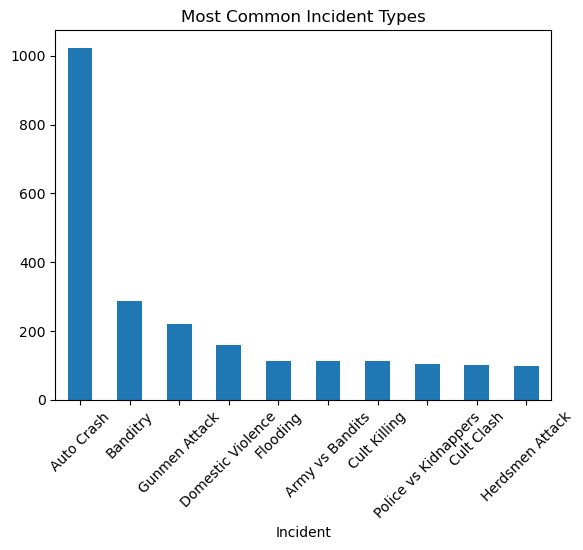

In [575]:
incident_counts.plot(kind='bar')
plt.title("Most Common Incident Types")
plt.xticks(rotation=45)
plt.show()

Certain incident types appear more frequently than others, indicating recurring patterns of violence or conflict.
Understanding these patterns can help in designing preventive strategies.

3.Which incidents result in the highest number of deaths?

In [576]:
top_deaths = df.sort_values(by='Number of deaths', ascending=False).head(10)
top_deaths[['Incident', 'State', 'Number of deaths']]

,Incident,State,Number of deaths
5433,Herdsmen Attack,Benue,244
2317,Heat Waves,Adamawa,210
5438,ISWAP vs Boko Haram,Borno,200
2817,Banditry,Katsina,200
6859,Army vs Boko Haram,Borno,200
1046,Petrol Tanker Explosion,Jigawa,186
1146,Boat Mishap,Niger,180
2223,Banditry,Zamfara,150
5940,Banditry,Zamfara,130
3396,Army Bombs Villagers,Kaduna,127


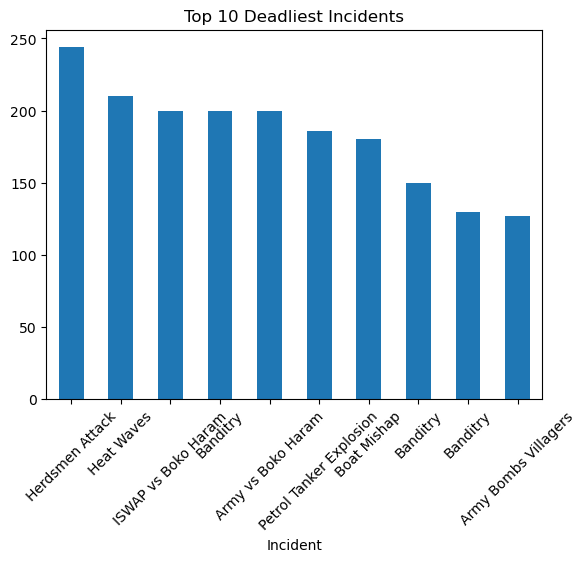

In [577]:
top_deaths.set_index('Incident')['Number of deaths'].plot(kind='bar')
plt.title("Top 10 Deadliest Incidents")
plt.xticks(rotation=45)
plt.show()

A small number of incidents account for a disproportionately high number of deaths.
These high-casualty events are critical areas for emergency response planning and prevention.

4. How have incidents changed over time?

In [578]:
df['Year'] = df['Start date'].dt.year

yearly_incidents = df.groupby('Year').size()
yearly_incidents

Year
2022.0    1653
2023.0    2604
2024.0    2610
2025.0     617
dtype: int64

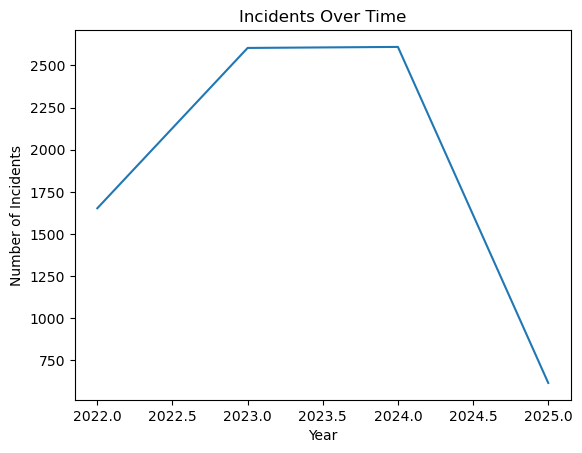

In [579]:
yearly_incidents.plot()
plt.title("Incidents Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.show()

The number of incidents fluctuates over time, with periods of increase and decrease.
This may reflect changes in security conditions or reporting practices.

5. What is the distribution of deaths across incidents?

In [580]:
df['Number of deaths'].describe()

count    7485.000000
mean        4.711824
std        11.165974
min         1.000000
25%         1.000000
50%         1.000000
75%         4.000000
max       244.000000
Name: Number of deaths, dtype: float64

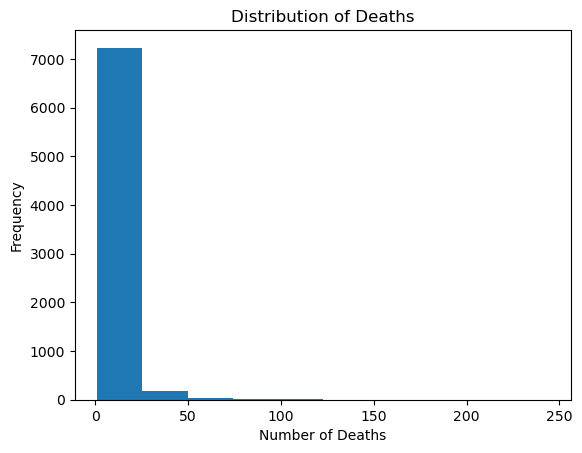

In [581]:
df['Number of deaths'].plot(kind='hist')
plt.title("Distribution of Deaths")
plt.xlabel("Number of Deaths")
plt.show()

Most incidents result in relatively low numbers of deaths, while a few incidents result in very high casualties.
This indicates a skewed distribution.

6. Are there states with consistently high casualty incidents?

In [582]:
state_deaths = df.groupby('State')['Number of deaths'].sum().sort_values(ascending=False).head(10)
state_deaths

State
Borno      5738
Kaduna     2578
Zamfara    2546
Niger      2468
Benue      2101
Katsina    2079
Plateau    1495
Lagos      1058
Ogun        977
Anambra     899
Name: Number of deaths, dtype: int64

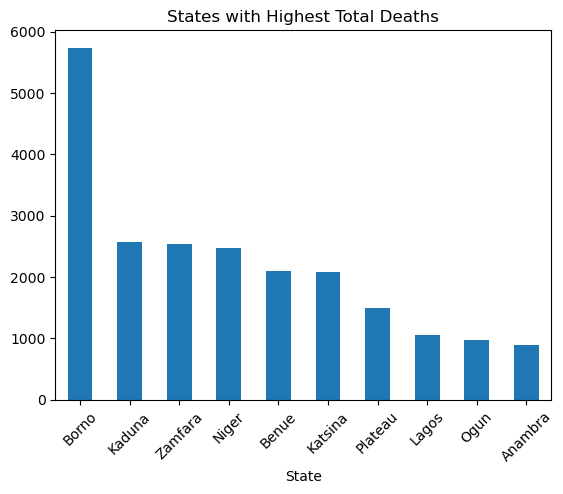

In [583]:
state_deaths.plot(kind='bar')
plt.title("States with Highest Total Deaths")
plt.xticks(rotation=45)
plt.show()

Certain states consistently record higher total deaths, indicating more severe or frequent violent incidents.
These states should be prioritized for intervention.

7. Is there a relationship between incident frequency and deaths?

In [584]:
state_summary = df.groupby('State').agg({
    'Incident': 'count',
    'Number of deaths': 'sum'
})

state_summary.columns = ['Incident Count', 'Total Deaths']
state_summary

,Incident Count,Total Deaths
State,,
(FCT) Abuja,319,738
Abia,128,464
Adamawa,84,503
Akwa Ibom,111,211
Anambra,282,899
Bauchi,183,815
Bayelsa,85,301
Benue,328,2101
Borno,315,5738


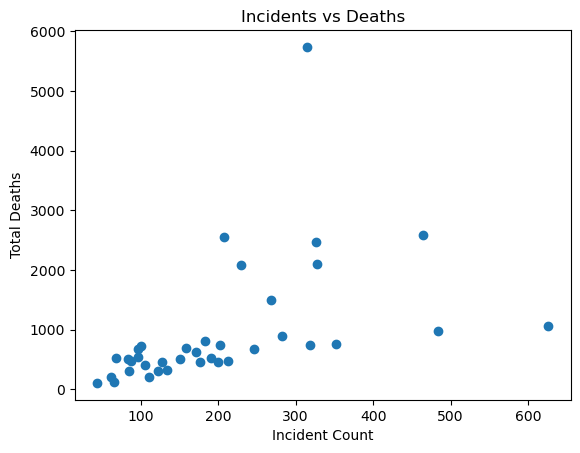

In [585]:
plt.scatter(state_summary['Incident Count'], state_summary['Total Deaths'])
plt.xlabel("Incident Count")
plt.ylabel("Total Deaths")
plt.title("Incidents vs Deaths")
plt.show()

There is a noticeable relationship between incident frequency and total deaths.
States with higher numbers of incidents tend to also have higher casualty figures.

### Data Cleaning (State Column)
The dataset contained inconsistent state names and formatting issues.
These were corrected by standardizing naming conventions and removing duplicates.
The 'State' column contained inconsistencies such as:
- Misspellings (e.g., Kastina → Katsina)
- Formatting issues (e.g., FCT variations)
- Numeric suffixes (e.g., Delta2)
These were corrected using string normalization and mapping techniques.


## Findings

- Certain incident types occur more frequently than others.
- Some locations have significantly higher incident rates.
- Most incidents result in low death counts, but a few have very high casualties.
- There is a noticeable trend in incidents over time.
Borno and Kaduna have high incident rates
- Most incidents have low death counts
- Some years show increased violence



## Recommendations

- Increase security in high-risk locations.
- Improve emergency response systems.
- Raise awareness about common incident causes.
- Government should monitor trends and act early.
- Improve security in high-risk states
- Strengthen early warning systems


In [586]:
df.to_csv('morin.csv')